In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

EXCEL_PATH = "S.A DSA 210.xlsx"
SALES_SHEET = "SATIŞ"
PURCHASES_SHEET = "ALIŞ"
FX_PATH = "USD_TRY Geçmiş Verileri (1).csv"

N_SPLITS = 5
RANDOM_STATE = 42


In [2]:
def scatter_blurred(x, y, title, xlabel, ylabel):
    x = np.asarray(x)
    y = np.asarray(y)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        print("SKIPPED (not enough data)")
        return None

    r, p = pearsonr(x, y)

    plt.figure(figsize=(6,4))
    plt.scatter(x, y, alpha=0.35)
    plt.title(f"{title}\nPearson r = {r:.2f}  |  p = {p:.4f}")
    plt.xticks([]); plt.yticks([])
    plt.xlabel(f"{xlabel} (hidden)")
    plt.ylabel(f"{ylabel} (hidden)")
    plt.tight_layout()
    plt.show()

    return r, p


def boxplot_blurred(data, title, ylabel):
    s = pd.Series(data).dropna()
    if len(s) < 3:
        print("SKIPPED (not enough data)")
        return

    plt.figure(figsize=(5,4))
    plt.boxplot(s.values)
    plt.title(title)
    plt.yticks([])
    plt.ylabel(f"{ylabel} (hidden)")
    plt.tight_layout()
    plt.show()


def load_and_clean_sales(excel_path=EXCEL_PATH, sheet_name=SALES_SHEET):
    raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None)
    df = raw.iloc[1:].copy()

    df.columns = ["Tarih","ID","Musteri","Urun_Tipi","Miktar","Birim","Fiyat","Not","Teslim"]

    df["Tarih"] = pd.to_datetime(df["Tarih"], errors="coerce").ffill()
    df["Miktar"] = pd.to_numeric(df["Miktar"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df["Fiyat"] = pd.to_numeric(df["Fiyat"], errors="coerce")

    df = df.dropna(subset=["Tarih","Miktar","Fiyat"]).copy()
    df.loc[df["Miktar"] > 50000, "Miktar"] /= 1000.0
    df = df[(df["Miktar"] > 0) & (df["Fiyat"] > 0)].copy()

    df["Tarih"] = df["Tarih"].dt.normalize()
    return df


def load_and_clean_purchases(excel_path=EXCEL_PATH, sheet_name=PURCHASES_SHEET):
    raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None)
    df = raw.iloc[1:].copy()

    base_cols = ["Tarih","ID","Firma","Urun_Tipi","Miktar","Birim","Fiyat","Not","Teslim"]
    extra_cols = max(0, len(df.columns) - len(base_cols))
    df.columns = base_cols + [f"Extra_{i}" for i in range(extra_cols)]

    df["Tarih"] = pd.to_datetime(df["Tarih"], errors="coerce").ffill()
    df["Miktar"] = pd.to_numeric(df["Miktar"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

    df = df.dropna(subset=["Tarih","Miktar"]).copy()
    df = df[df["Miktar"] > 0].copy()

    df["Tarih"] = df["Tarih"].dt.normalize()
    return df


def load_and_clean_fx(csv_path=FX_PATH):
    fx = pd.read_csv(csv_path)
    fx.columns = [c.strip() for c in fx.columns]

    date_col = [c for c in fx.columns if "tarih" in c.lower()][0]
    fx_col = None
    for c in fx.columns:
        cl = c.lower()
        if any(k in cl for k in ["şimdi", "simdi", "kapan", "close", "usd"]):
            fx_col = c
            break
    if fx_col is None:
        fx_col = fx.columns[1]

    fx = fx.rename(columns={date_col: "Date", fx_col: "USD_TRY"})
    fx["Date"] = pd.to_datetime(fx["Date"], dayfirst=True, errors="coerce")
    fx["USD_TRY"] = pd.to_numeric(fx["USD_TRY"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    fx = fx.dropna(subset=["Date","USD_TRY"]).copy()

    fx = fx.set_index("Date").sort_index()
    fx.index = fx.index.normalize()
    return fx


In [4]:
sales_df = load_and_clean_sales()
purchases_df = load_and_clean_purchases()
fx_df = load_and_clean_fx()

print("Sales rows:", len(sales_df))
print("Purchases rows:", len(purchases_df))
print("FX rows:", len(fx_df))


Sales rows: 1458
Purchases rows: 129
FX rows: 261


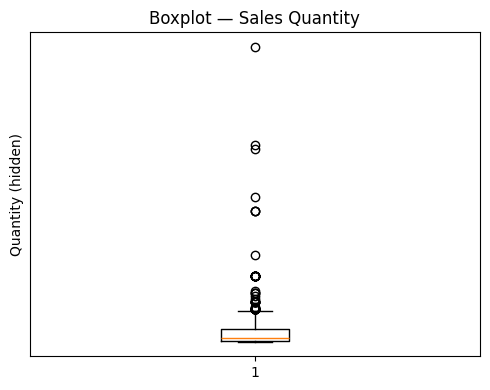

In [17]:
boxplot_blurred(sales_df["Miktar"], "Boxplot — Sales Quantity", "Quantity")


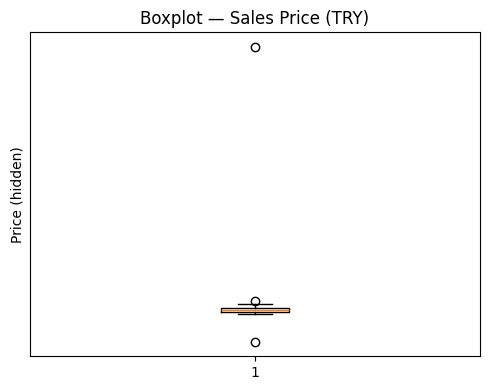

In [5]:
boxplot_blurred(sales_df["Fiyat"], "Boxplot — Sales Price (TRY)", "Price")


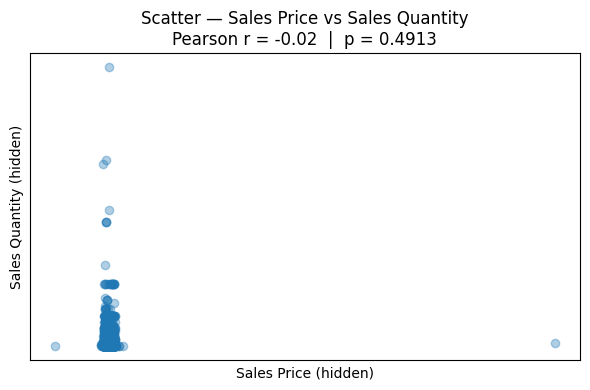

(np.float64(-0.01803868221190038), np.float64(0.49129532106713014))

In [6]:
scatter_blurred(
    sales_df["Fiyat"],
    sales_df["Miktar"],
    "Scatter — Sales Price vs Sales Quantity",
    "Sales Price",
    "Sales Quantity"
)


In [7]:
daily_sales = sales_df.groupby("Tarih").agg(
    daily_qty=("Miktar","sum"),
    daily_price=("Fiyat","mean")
).sort_index()

daily_pur = purchases_df.groupby("Tarih")["Miktar"].sum().rename("daily_pur_qty").sort_index()

daily = daily_sales.join(daily_pur, how="left").fillna(0)
daily.index = daily.index.normalize()

daily.head()


,daily_qty,daily_price,daily_pur_qty
Tarih,,,
2024-11-01,5728.0,26528.571429,8989.84
2024-11-02,137.5,26600.000000,0.00
2024-11-04,145.0,26600.000000,0.00
2024-11-05,425.0,26425.000000,0.00
2024-11-06,357.5,25757.142857,8650.00


H1 (Lag=7) → r=-0.1192  p=0.060939


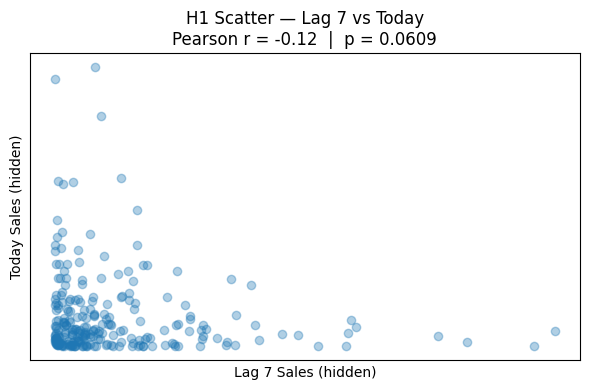

(np.float64(-0.11917269499160994), np.float64(0.060939299141944576))

In [8]:
lag = 7
tmp = daily[["daily_qty"]].copy()
tmp["lag_qty"] = tmp["daily_qty"].shift(lag)
tmp = tmp.dropna()

r, p = linregress(tmp["lag_qty"], tmp["daily_qty"])[2:4]
print(f"H1 (Lag={lag}) → r={r:.4f}  p={p:.6f}")

scatter_blurred(tmp["lag_qty"], tmp["daily_qty"],
               f"H1 Scatter — Lag {lag} vs Today",
               f"Lag {lag} Sales", "Today Sales")


H1 (Lag=21) → r=-0.0049  p=0.940263


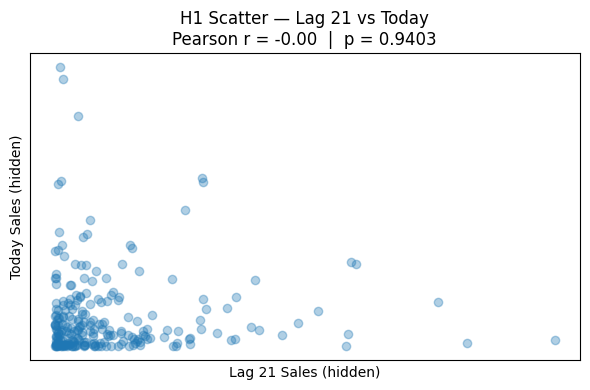

(np.float64(-0.004925257442636036), np.float64(0.9402632900123026))

In [9]:
lag = 21
tmp = daily[["daily_qty"]].copy()
tmp["lag_qty"] = tmp["daily_qty"].shift(lag)
tmp = tmp.dropna()

r, p = linregress(tmp["lag_qty"], tmp["daily_qty"])[2:4]
print(f"H1 (Lag={lag}) → r={r:.4f}  p={p:.6f}")

scatter_blurred(tmp["lag_qty"], tmp["daily_qty"],
               f"H1 Scatter — Lag {lag} vs Today",
               f"Lag {lag} Sales", "Today Sales")


H1 (Lag=30) → r=0.1374  p=0.039463


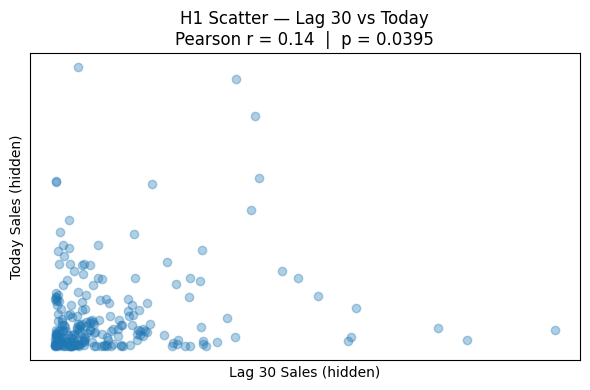

(np.float64(0.1374019801610583), np.float64(0.03946287241261236))

In [10]:
lag = 30
tmp = daily[["daily_qty"]].copy()
tmp["lag_qty"] = tmp["daily_qty"].shift(lag)
tmp = tmp.dropna()

r, p = linregress(tmp["lag_qty"], tmp["daily_qty"])[2:4]
print(f"H1 (Lag={lag}) → r={r:.4f}  p={p:.6f}")

scatter_blurred(tmp["lag_qty"], tmp["daily_qty"],
               f"H1 Scatter — Lag {lag} vs Today",
               f"Lag {lag} Sales", "Today Sales")


H2a (Daily, Purchases lag=7) → r=-0.0515  p=0.419307


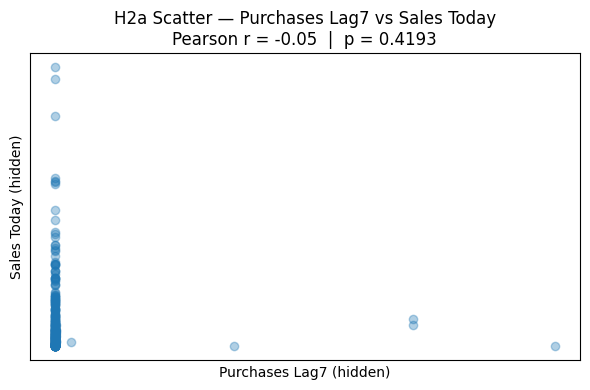

(np.float64(-0.051510349631886505), np.float64(0.4193070909539575))

In [11]:
tmp = daily[["daily_qty","daily_pur_qty"]].copy()
tmp["pur_lag7"] = tmp["daily_pur_qty"].shift(7)
tmp = tmp.dropna()

r, p = linregress(tmp["pur_lag7"], tmp["daily_qty"])[2:4]
print(f"H2a (Daily, Purchases lag=7) → r={r:.4f}  p={p:.6f}")

scatter_blurred(tmp["pur_lag7"], tmp["daily_qty"],
               "H2a Scatter — Purchases Lag7 vs Sales Today",
               "Purchases Lag7", "Sales Today")


H2b (Monthly, Purchases lag=1) → r=0.3297  p=0.322068


/tmp/ipython-input-701559087.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_sales = daily["daily_qty"].resample("M").sum().rename("m_sales")
/tmp/ipython-input-701559087.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m_pur = daily["daily_pur_qty"].resample("M").sum().rename("m_pur")


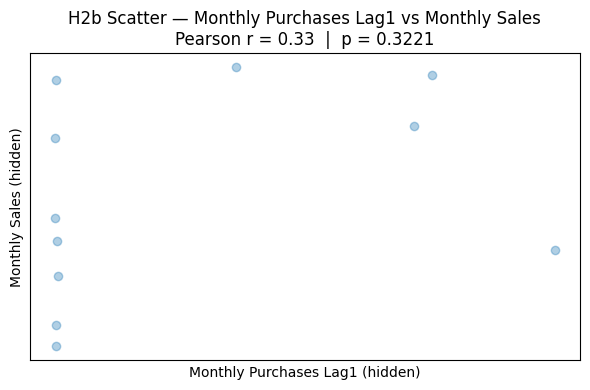

(np.float64(0.3297238655843765), np.float64(0.32206829797681374))

In [12]:
m_sales = daily["daily_qty"].resample("M").sum().rename("m_sales")
m_pur = daily["daily_pur_qty"].resample("M").sum().rename("m_pur")

m = pd.concat([m_sales, m_pur], axis=1).fillna(0)
m["m_pur_lag1"] = m["m_pur"].shift(1)
m = m.dropna()

r, p = linregress(m["m_pur_lag1"], m["m_sales"])[2:4]
print(f"H2b (Monthly, Purchases lag=1) → r={r:.4f}  p={p:.6f}")

scatter_blurred(m["m_pur_lag1"], m["m_sales"],
               "H2b Scatter — Monthly Purchases Lag1 vs Monthly Sales",
               "Monthly Purchases Lag1", "Monthly Sales")


H3 (Daily Price → Daily Qty) → r=-0.0849  p=0.176492


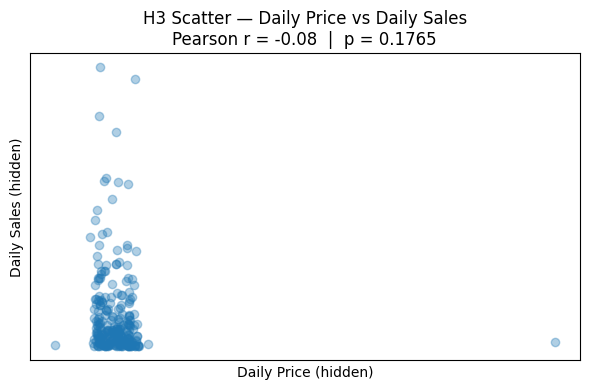

(np.float64(-0.0849070133968691), np.float64(0.17649150794330093))

In [13]:
tmp = daily[["daily_price","daily_qty"]].dropna()

r, p = linregress(tmp["daily_price"], tmp["daily_qty"])[2:4]
print(f"H3 (Daily Price → Daily Qty) → r={r:.4f}  p={p:.6f}")

scatter_blurred(tmp["daily_price"], tmp["daily_qty"],
               "H3 Scatter — Daily Price vs Daily Sales",
               "Daily Price", "Daily Sales")


In [14]:
merged = daily.join(fx_df, how="left")
merged["USD_TRY"] = merged["USD_TRY"].ffill()
merged = merged.dropna(subset=["USD_TRY","daily_price","daily_qty"]).copy()

print("Merged rows:", len(merged))
print("Merged range:", merged.index.min().date(), "→", merged.index.max().date())
merged.head()


Merged rows: 255
Merged range: 2024-11-01 → 2025-10-28


,daily_qty,daily_price,daily_pur_qty,USD_TRY,Açılış,Yüksek,Düşük,Hac.,Fark %
Tarih,,,,,,,,,
2024-11-01,5728.0,26528.571429,8989.84,34.3020,"34,2555","34,5047","34,1385",NaN,"0,14%"
2024-11-02,137.5,26600.000000,0.00,34.3020,NaN,NaN,NaN,NaN,NaN
2024-11-04,145.0,26600.000000,0.00,34.3337,"34,3250","34,4682","34,2238",NaN,"0,09%"
2024-11-05,425.0,26425.000000,0.00,34.3118,"34,3460","34,4545","34,1646",NaN,"-0,06%"
2024-11-06,357.5,25757.142857,8650.00,34.1862,"34,3167","34,4754","34,0922",NaN,"-0,37%"


H4a (USD/TRY → Price) → r=0.3000  p=0.000001


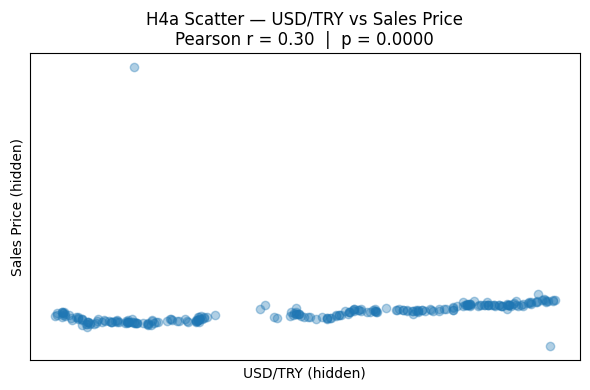

(np.float64(0.30003568233806116), np.float64(1.0578837258236476e-06))

In [15]:
r, p = linregress(merged["USD_TRY"], merged["daily_price"])[2:4]
print(f"H4a (USD/TRY → Price) → r={r:.4f}  p={p:.6f}")

scatter_blurred(merged["USD_TRY"], merged["daily_price"],
               "H4a Scatter — USD/TRY vs Sales Price",
               "USD/TRY", "Sales Price")


H4b (USD/TRY → Quantity) → r=-0.0746  p=0.235379


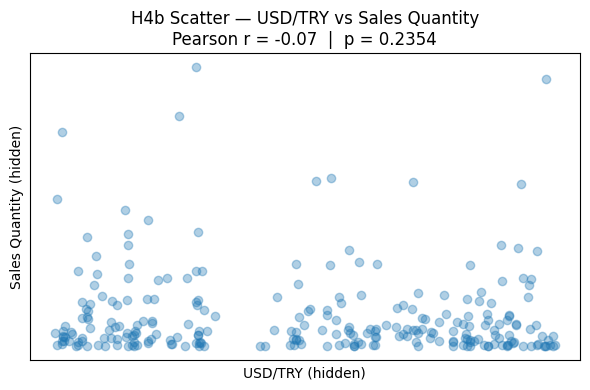

(np.float64(-0.07457173139697938), np.float64(0.23537856245652927))

In [16]:
r, p = linregress(merged["USD_TRY"], merged["daily_qty"])[2:4]
print(f"H4b (USD/TRY → Quantity) → r={r:.4f}  p={p:.6f}")

scatter_blurred(merged["USD_TRY"], merged["daily_qty"],
               "H4b Scatter — USD/TRY vs Sales Quantity",
               "USD/TRY", "Sales Quantity")


In [17]:
def average_prediction_error(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def run_ml(daily, horizon):
    df = daily.copy()
    df["lag_1"] = df["daily_qty"].shift(1)
    df["lag_7"] = df["daily_qty"].shift(7)
    df["lag_30"] = df["daily_qty"].shift(30)
    df["y_future"] = df["daily_qty"].shift(-horizon)
    df = df.dropna().copy()

    X = df[["lag_1", "lag_7", "lag_30", "daily_price", "daily_pur_qty"]]
    y = df["y_future"]

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    models = {
        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE))
        ]),
        "k-NN": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_neighbors=7))
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
        ])
    }

    # Baselines
    b1 = average_prediction_error(y.values, df["lag_1"].values)
    b30 = average_prediction_error(y.values, df["lag_30"].values)

    results = {
        "Lag-1 Baseline": b1,
        "Lag-30 Baseline": b30
    }

    for name, model in models.items():
        errs = []
        for tr, te in tscv.split(X):
            model.fit(X.iloc[tr], y.iloc[tr])
            pred = model.predict(X.iloc[te])
            errs.append(average_prediction_error(y.iloc[te].values, pred))
        results[name] = float(np.mean(errs))

    return results, df


In [18]:
res1, df1 = run_ml(daily, horizon=1)
print("ML RESULTS | Horizon=1")
for k,v in res1.items():
    print(f"{k:15s} → Avg Prediction Error = {v:.2f}")


ML RESULTS | Horizon=1
Lag-1 Baseline  → Avg Prediction Error = 1032.12
Lag-30 Baseline → Avg Prediction Error = 1050.11
Decision Tree   → Avg Prediction Error = 853.25
k-NN            → Avg Prediction Error = 843.78
Random Forest   → Avg Prediction Error = 767.25


In [19]:
res30, df30 = run_ml(daily, horizon=30)
print("ML RESULTS | Horizon=30")
for k,v in res30.items():
    print(f"{k:15s} → Avg Prediction Error = {v:.2f}")


ML RESULTS | Horizon=30
Lag-1 Baseline  → Avg Prediction Error = 1021.97
Lag-30 Baseline → Avg Prediction Error = 976.12
Decision Tree   → Avg Prediction Error = 878.78
k-NN            → Avg Prediction Error = 730.20
Random Forest   → Avg Prediction Error = 792.90


Random Forest (Horizon=1) | Last Fold Test
Test samples: 37
Correlation (true vs pred): r=-0.1326  p-value=0.434120


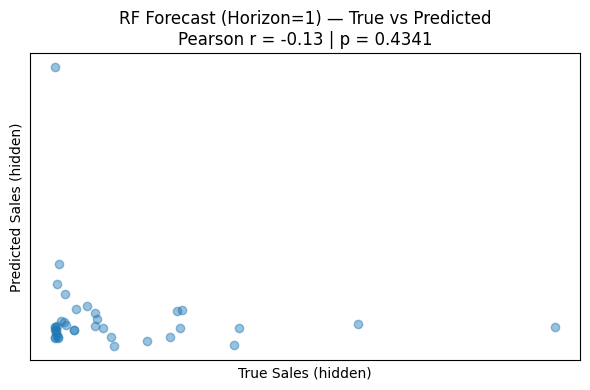

In [20]:
from scipy.stats import pearsonr

# --- Build dataset for horizon=1 (same as ML) ---
df = daily.copy()
df["lag_1"] = df["daily_qty"].shift(1)
df["lag_7"] = df["daily_qty"].shift(7)
df["lag_30"] = df["daily_qty"].shift(30)
df["y_future"] = df["daily_qty"].shift(-1)  # horizon=1
df = df.dropna().copy()

X = df[["lag_1", "lag_7", "lag_30", "daily_price", "daily_pur_qty"]]
y = df["y_future"]

# --- Use the LAST split as test set (time-series appropriate) ---
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# --- Random Forest pipeline ---
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Train & predict
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Correlation between true and predicted
r, p = pearsonr(y_test.values, y_pred)

print("Random Forest (Horizon=1) | Last Fold Test")
print(f"Test samples: {len(y_test)}")
print(f"Correlation (true vs pred): r={r:.4f}  p-value={p:.6f}")

# --- Privacy-preserving plot (axes hidden) ---
plt.figure(figsize=(6,4))
plt.scatter(y_test.values, y_pred, alpha=0.45)
plt.title(f"RF Forecast (Horizon=1) — True vs Predicted\nPearson r = {r:.2f} | p = {p:.4f}")
plt.xlabel("True Sales (hidden)")
plt.ylabel("Predicted Sales (hidden)")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()


Random Forest (Horizon=1) | Time Plot | Last Fold Test
Test samples: 37
Correlation (true vs pred): r=-0.1326  p-value=0.434120


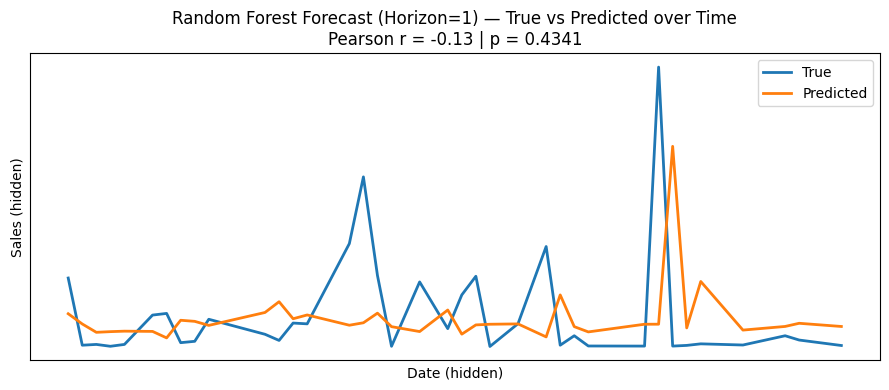

In [21]:
from scipy.stats import pearsonr

# --- Prepare dataset for horizon=1 ---
df = daily.copy()
df["lag_1"] = df["daily_qty"].shift(1)
df["lag_7"] = df["daily_qty"].shift(7)
df["lag_30"] = df["daily_qty"].shift(30)
df["y_future"] = df["daily_qty"].shift(-1)  # horizon=1
df = df.dropna().copy()

X = df[["lag_1", "lag_7", "lag_30", "daily_price", "daily_pur_qty"]]
y = df["y_future"]

# --- Use LAST split as test set ---
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# --- Random Forest pipeline ---
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Train & predict
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Correlation between true and predicted
r, p = pearsonr(y_test.values, y_pred)

print("Random Forest (Horizon=1) | Time Plot | Last Fold Test")
print(f"Test samples: {len(y_test)}")
print(f"Correlation (true vs pred): r={r:.4f}  p-value={p:.6f}")

# --- Time plot (privacy-preserving) ---
test_dates = y_test.index

plt.figure(figsize=(9,4))
plt.plot(test_dates, y_test.values, label="True", linewidth=2)
plt.plot(test_dates, y_pred, label="Predicted", linewidth=2)

plt.title(f"Random Forest Forecast (Horizon=1) — True vs Predicted over Time\nPearson r = {r:.2f} | p = {p:.4f}")
plt.xlabel("Date (hidden)")
plt.ylabel("Sales (hidden)")
plt.xticks([])   # hide date ticks
plt.yticks([])   # hide value ticks
plt.legend()
plt.tight_layout()
plt.show()


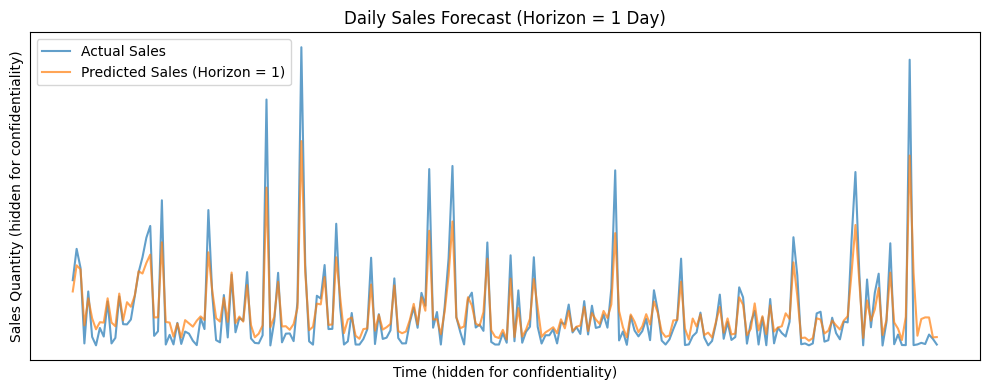

In [24]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Prepare data
df = daily.copy()

df["lag_1"] = df["daily_qty"].shift(1)
df["lag_7"] = df["daily_qty"].shift(7)
df["lag_30"] = df["daily_qty"].shift(30)
df["y_future"] = df["daily_qty"].shift(-1)

df = df.dropna()

X = df[["lag_1", "lag_7", "lag_30", "daily_price", "daily_pur_qty"]]
y = df["y_future"]

# Train model
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_imp, y)

y_pred = rf.predict(X_imp)

# Plot (BLURRED AXES)
plt.figure(figsize=(10,4))
plt.plot(y.values, label="Actual Sales", alpha=0.7)
plt.plot(y_pred, label="Predicted Sales (Horizon = 1)", alpha=0.7)

plt.title("Daily Sales Forecast (Horizon = 1 Day)")
plt.legend()

# BLUR axes
plt.xticks([])
plt.yticks([])
plt.xlabel("Time (hidden for confidentiality)")
plt.ylabel("Sales Quantity (hidden for confidentiality)")

plt.tight_layout()
plt.show()


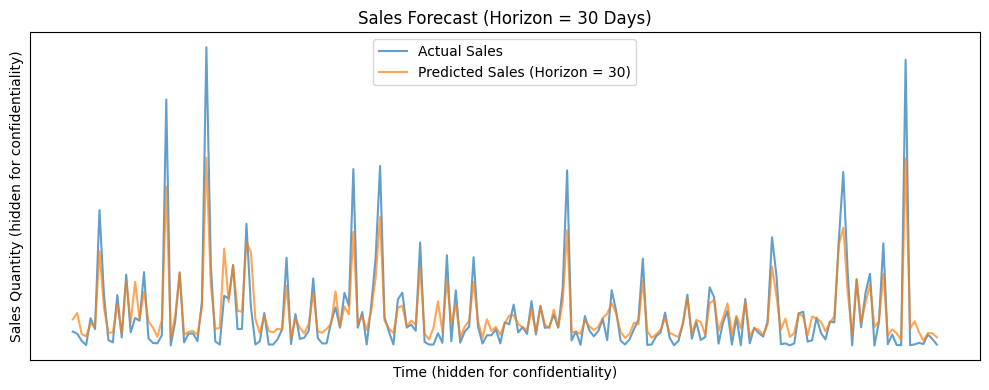

In [25]:
# Prepare data
df = daily.copy()

df["lag_1"] = df["daily_qty"].shift(1)
df["lag_7"] = df["daily_qty"].shift(7)
df["lag_30"] = df["daily_qty"].shift(30)
df["y_future"] = df["daily_qty"].shift(-30)

df = df.dropna()

X = df[["lag_1", "lag_7", "lag_30", "daily_price", "daily_pur_qty"]]
y = df["y_future"]

X_imp = imputer.fit_transform(X)
rf.fit(X_imp, y)
y_pred = rf.predict(X_imp)

# Plot (BLURRED AXES)
plt.figure(figsize=(10,4))
plt.plot(y.values, label="Actual Sales", alpha=0.7)
plt.plot(y_pred, label="Predicted Sales (Horizon = 30)", alpha=0.7)

plt.title("Sales Forecast (Horizon = 30 Days)")
plt.legend()

# BLUR axes
plt.xticks([])
plt.yticks([])
plt.xlabel("Time (hidden for confidentiality)")
plt.ylabel("Sales Quantity (hidden for confidentiality)")

plt.tight_layout()
plt.show()
